# Accessibility: inspect every view

This notebook demonstrates why color, markers, and linestyles should be combined. Every figure is followed by the original, grayscale, print-stress and three Machado CVD simulations.

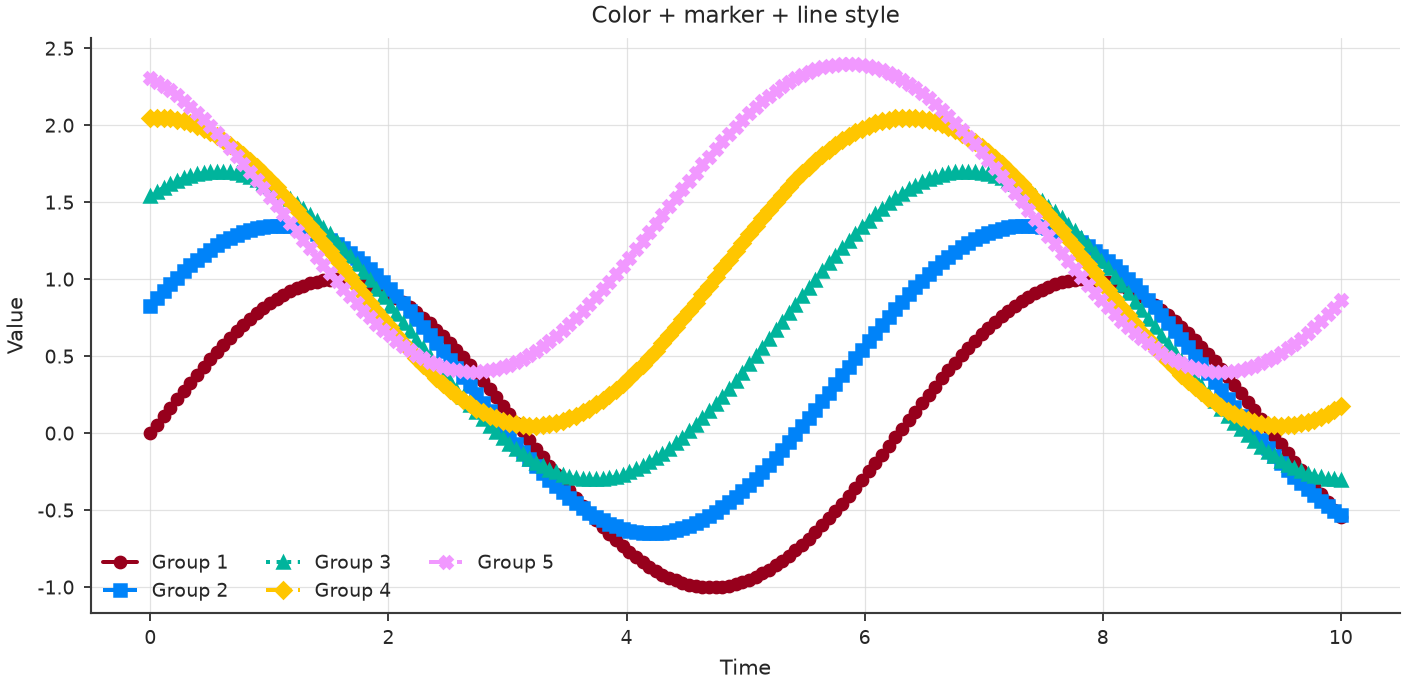

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import contrastcolors as cc
cc.set_style("heri", font="DejaVu Sans")
x = np.linspace(0, 10, 180)
fig, ax = plt.subplots(figsize=(8, 4))
for i in range(5):
    ax.plot(x, np.sin(x+i*0.5)+i*0.35, label=f"Group {i+1}")
ax.legend(ncol=3)
ax.set(title="Color + marker + line style", xlabel="Time", ylabel="Value")
fig.tight_layout()

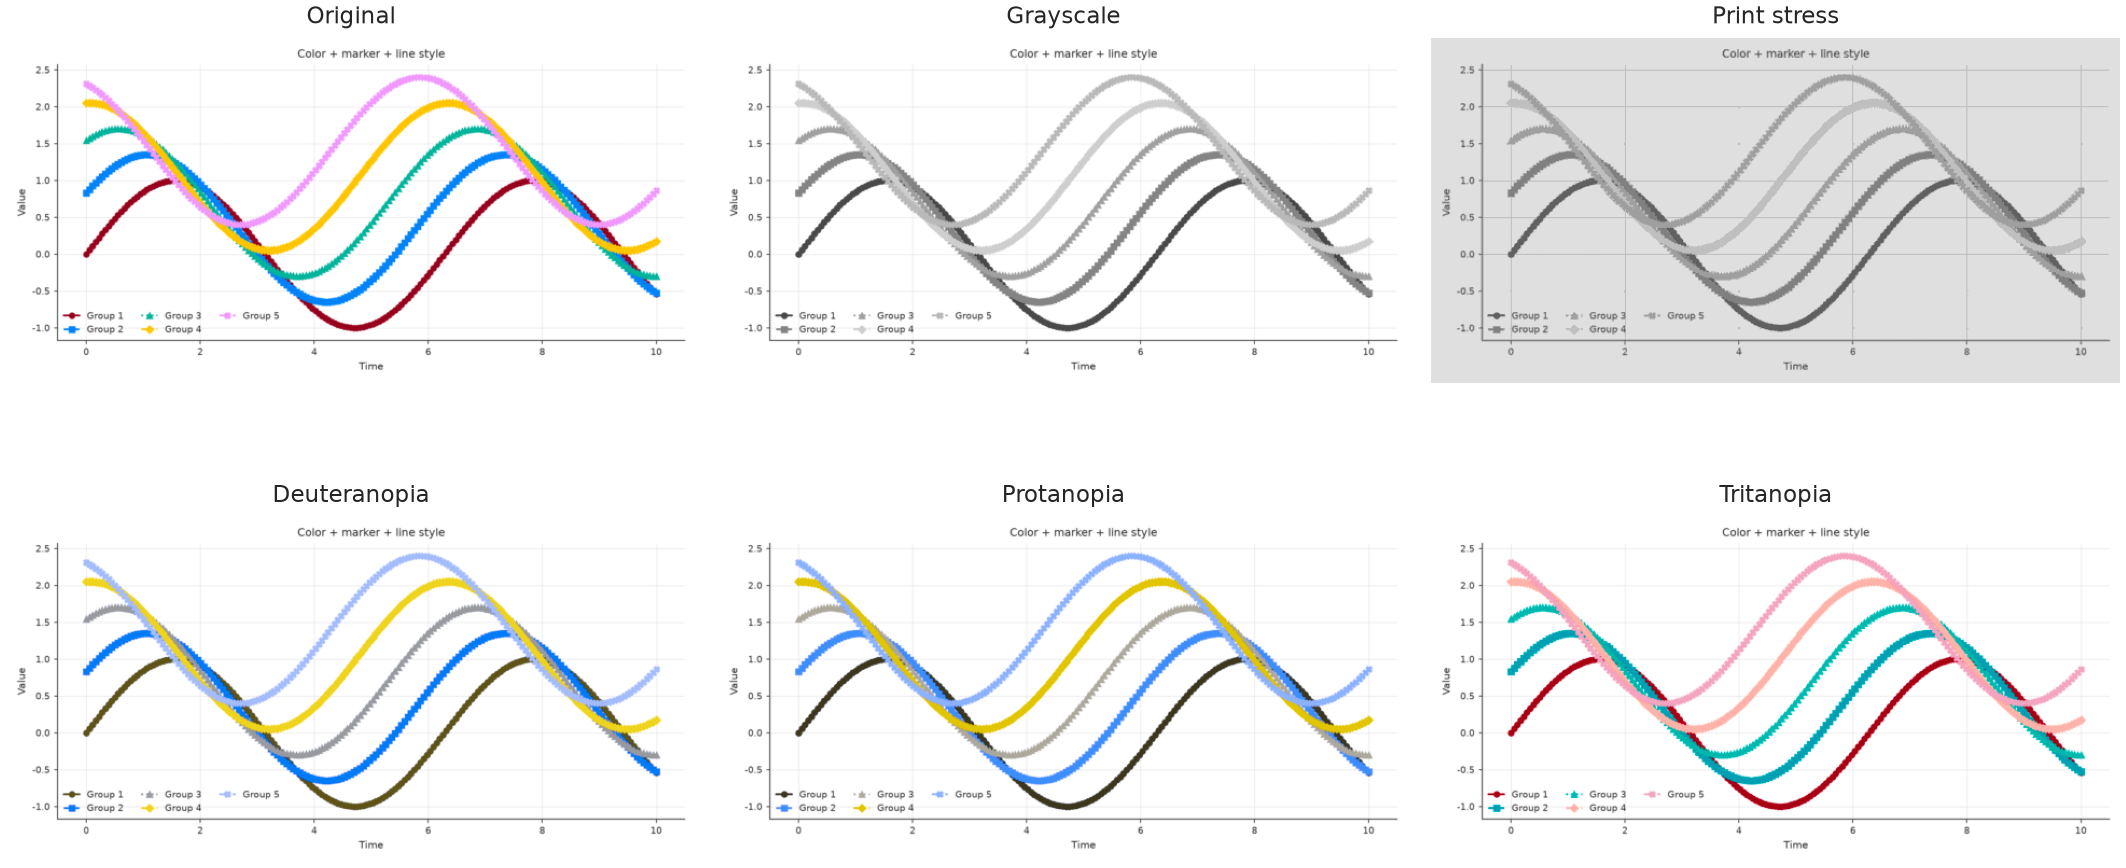

In [2]:
cc.show_accessibility_panel(fig, max_width=640)
plt.show()

## Scatter groups

Markers vary by group, not by individual observation.

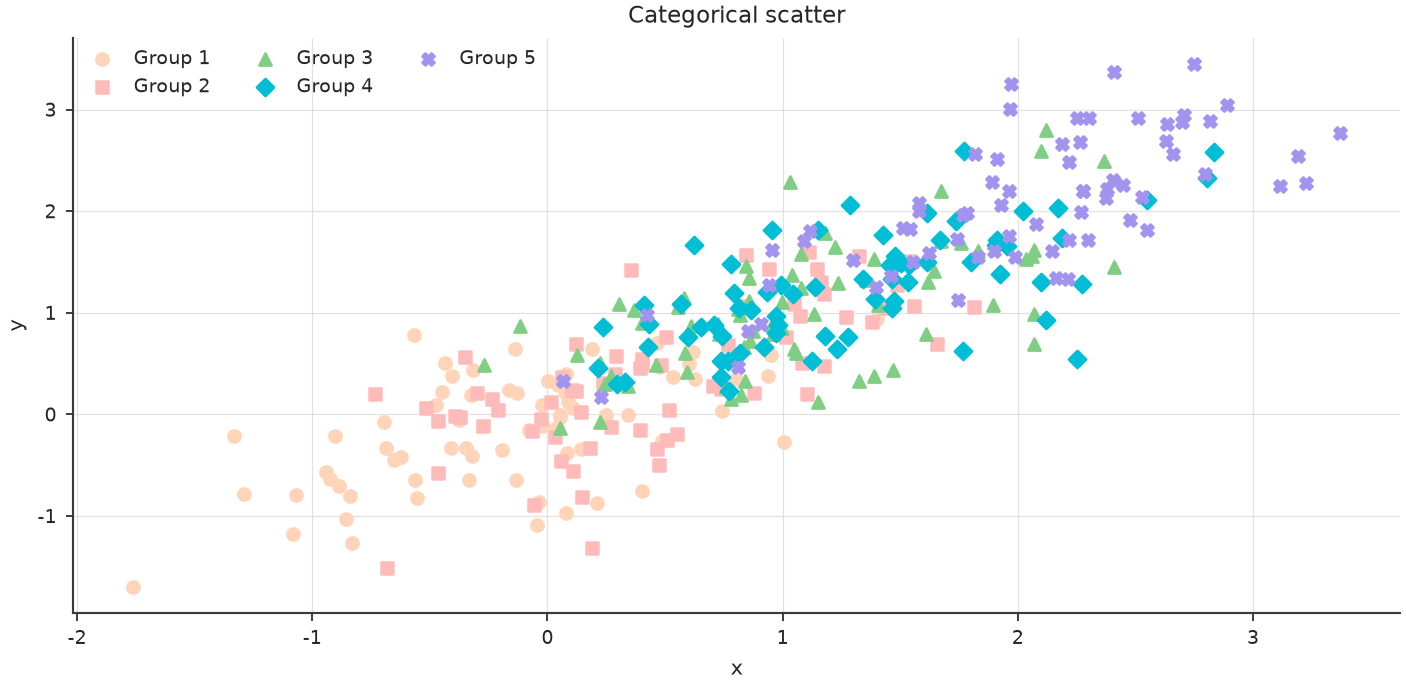

In [3]:
rng = np.random.default_rng(7)
fig, ax = plt.subplots(figsize=(8, 4))
scheme = cc.scatter_scheme([55,20,145,210,290],ratio=1.18,start_luminance=0.72)
for i, style in enumerate(scheme):
    xx = rng.normal(i*0.5, 0.7, 70)
    yy = 0.6*xx+rng.normal(i*0.2,0.5,70)
    ax.scatter(xx, yy, label=f"Group {i+1}", s=24, **style)
ax.legend(ncol=3)
ax.set(title="Categorical scatter", xlabel="x", ylabel="y")
fig.tight_layout()

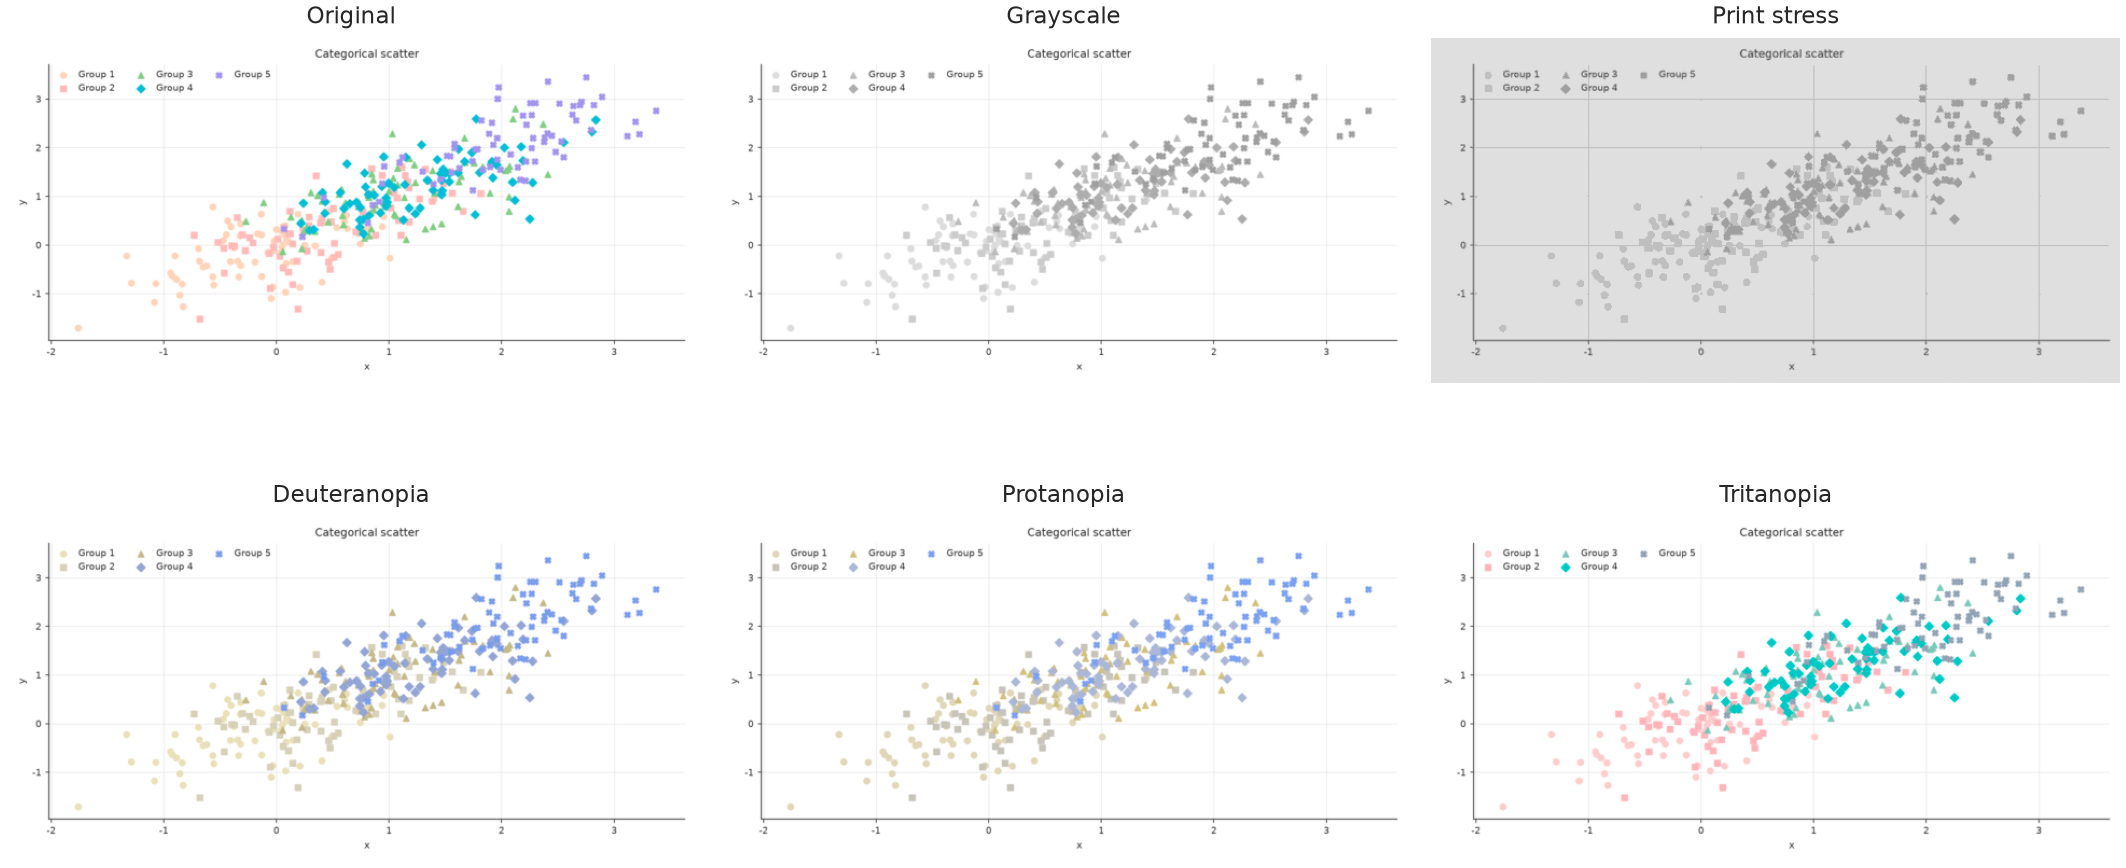

In [4]:
cc.show_accessibility_panel(fig, max_width=640)
plt.show()

## Continuous heatmap

Simulation reveals where color gradients may be hard to distinguish, even when categorical palettes are fine.

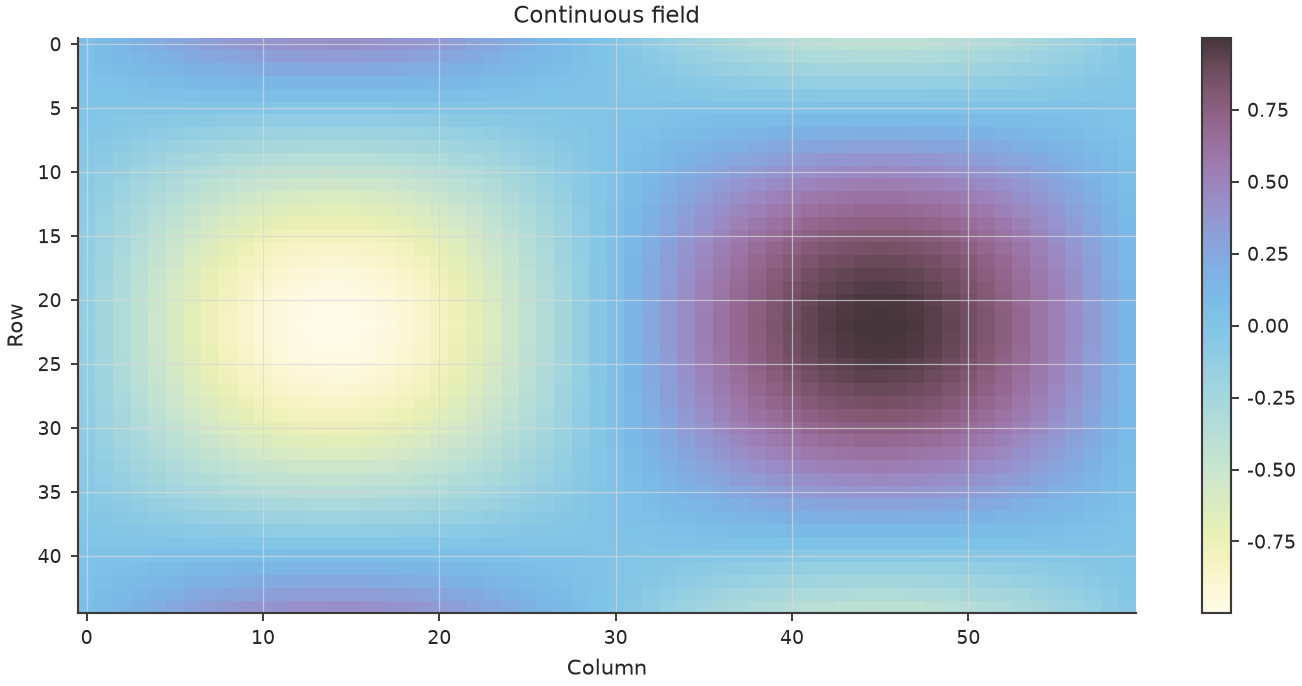

In [5]:
xx, yy = np.meshgrid(np.linspace(-3,3,60), np.linspace(-2,2,45))
z = np.sin(xx)*np.cos(yy)
fig, ax = plt.subplots(figsize=(8,4))
im = ax.imshow(z, cmap=cc.HERI_CMAP, aspect="auto")
fig.colorbar(im, ax=ax)
ax.set(title="Continuous field", xlabel="Column", ylabel="Row")
fig.tight_layout()

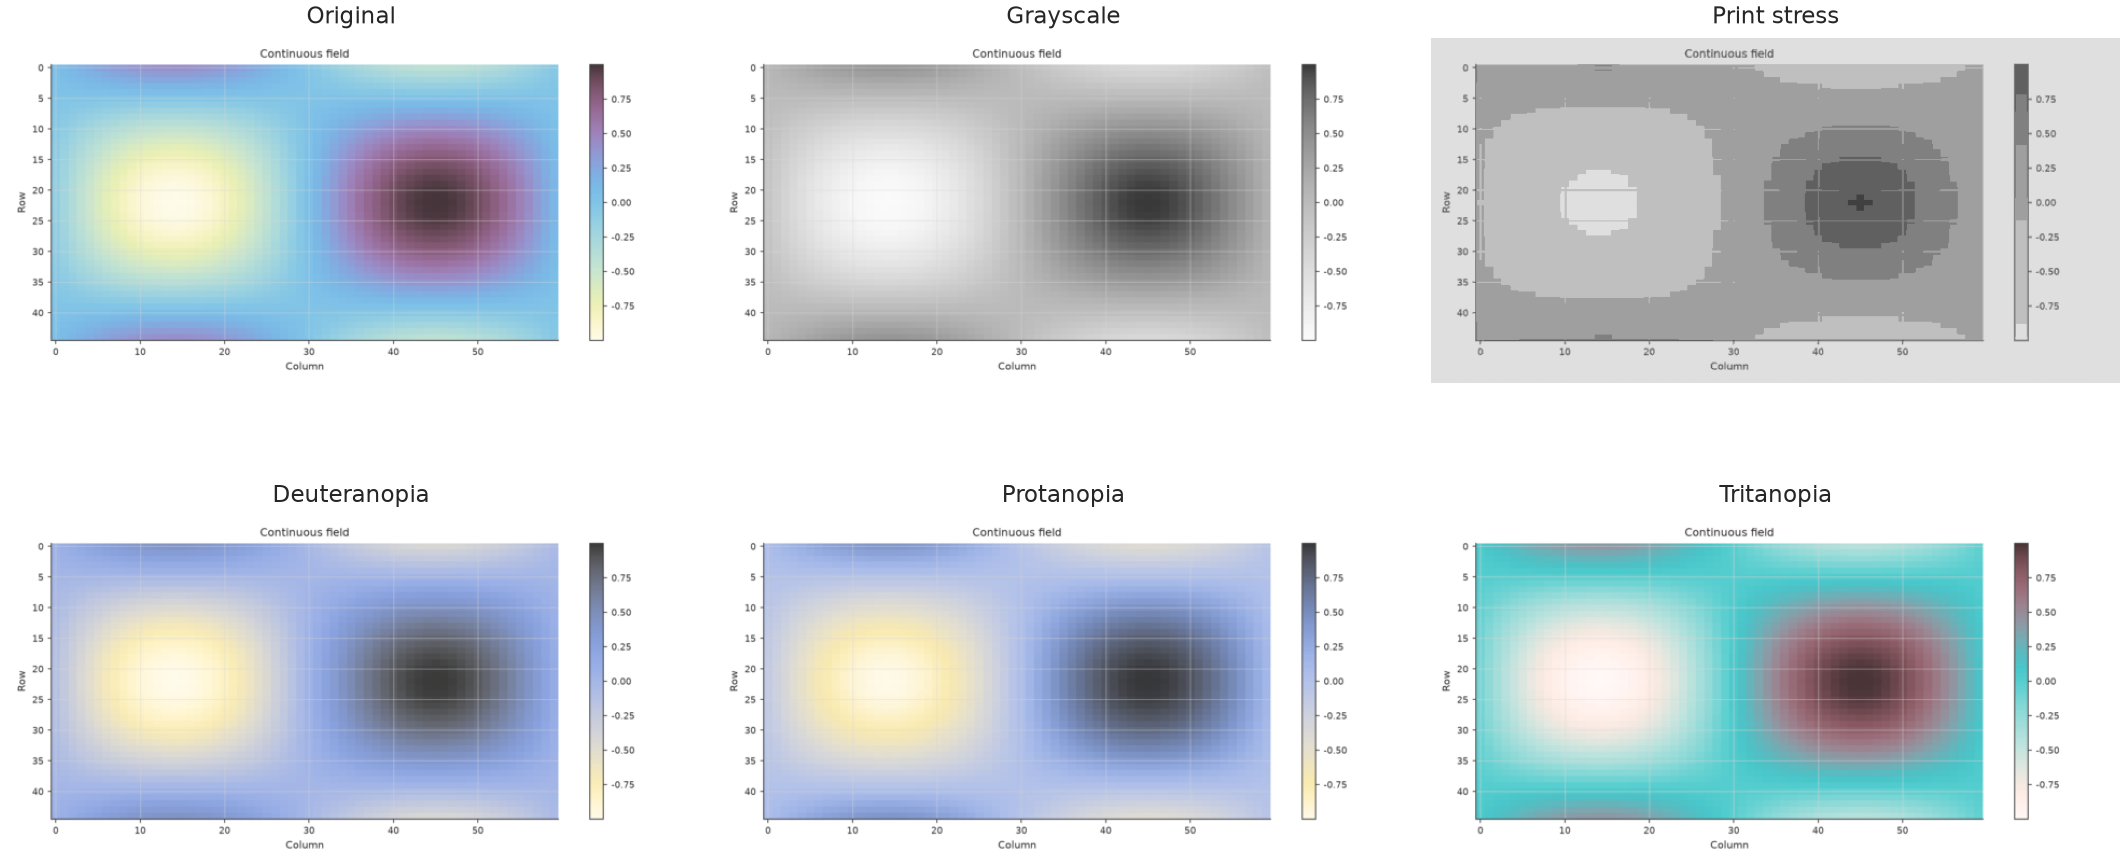

In [6]:
cc.show_accessibility_panel(fig, max_width=640)
plt.show()